# 📊 사회 수행평가: 대한민국 남녀 인구 변화 분석 및 2030년 인구수 예측

**탐구 주제**: 과거부터 현재까지의 인구 데이터를 바탕으로 대한민국의 인구 변화 추이를 살펴보고, 머신러닝(다항 회귀)을 활용해 2030년의 남녀 인구수를 예측해 봅니다.

**탐구 목적**: 
최근 대한민국의 저출산 및 고령화 문제가 심각한 사회적 이슈로 대두되고 있습니다. 본 데이터 분석을 통해 실제 인구가 어떻게 변화해 왔는지 객관적인 수치로 확인하고, 2030년의 인구 구조를 예측해 봄으로써 다가올 미래 사회의 변화와 문제점을 고찰해 보고자 합니다.

## 1. 데이터 분석 준비하기
데이터 분석과 머신러닝 모델 학습, 그리고 시각화를 위해 필요한 파이썬 라이브러리들을 설치하고 불러옵니다.

In [23]:
%pip install pandas scikit-learn matplotlib koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib # 그래프에서 한글이 깨지지 않게 해주는 라이브러리
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## 2. 데이터 불러오기 및 전처리
통계청 등의 자료를 바탕으로 한 `인구수.csv` 파일을 불러옵니다. 연도별로 남녀 인구수가 어떻게 기록되어 있는지 상위 5개 데이터를 확인합니다.

In [ ]:
# 데이터 불러오기 및 컬럼명 지정 (데이터 인코딩 오류 방지)
df = pd.read_csv('인구수.csv')
df.columns = ['연도', '남자인구수', '여자인구수']
df

,연도,남자인구수,여자인구수
0,1992,22345897,22157303
1,1993,22602933,22398180
2,1994,22814974,22601365
3,1995,23041367,22816662
4,1996,23242707,23023549


## 3. 머신러닝 모델 학습 (인구수 예측 알고리즘)
인구 변화는 단순한 직선(선형)이 아니라 곡선(비선형)의 형태를 띠는 경우가 많습니다. 따라서 인구수의 증감 추세를 더 잘 반영하기 위해 **다항 회귀(Polynomial Regression)** 분석 기법을 사용합니다.

In [26]:
# 입력 데이터(X: 연도)와 정답 데이터(y: 인구수) 나누기
X = df[['연도']]
y_male = df['남자인구수']
y_female = df['여자인구수']

# 단순한 직선이 아닌 곡선 형태의 예측을 위해 2차식 데이터로 변환
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 남자 인구수 예측 모델 학습시키기
model_male = LinearRegression()
model_male.fit(X_poly, y_male)

# 여자 인구수 예측 모델 학습시키기
model_female = LinearRegression()
model_female.fit(X_poly, y_female)

LinearRegression()

## 4. 2030년 대한민국 인구수 예측 결과
학습된 인공지능 모델에게 '2030년'이라는 조건을 주고, 예상되는 남녀 인구수를 질문해 봅니다.

In [27]:
# 2030년 데이터 생성 및 변환
X_2030 = pd.DataFrame({'연도': [2030]})
X_2030_poly = poly.transform(X_2030)

# 인구수 예측하기
pred_male_2030 = model_male.predict(X_2030_poly)[0]
pred_female_2030 = model_female.predict(X_2030_poly)[0]

# 결과 출력
print("======================================")
print(f"📉 2030년 예상 남자 인구수: {pred_male_2030:,.0f}명")
print(f"📉 2030년 예상 여자 인구수: {pred_female_2030:,.0f}명")
print(f"👨‍👩‍👧‍👦 2030년 예상 총 인구수: {(pred_male_2030 + pred_female_2030):,.0f}명")
print("======================================")

📉 2030년 예상 남자 인구수: 25,413,295명
📉 2030년 예상 여자 인구수: 25,825,458명
👨‍👩‍👧‍👦 2030년 예상 총 인구수: 51,238,754명


## 5. 인구 변화 추이 시각화 및 결론
과거의 인구 데이터와 2030년까지의 예측 데이터를 하나의 그래프로 묶어 시각화합니다. 이를 통해 인구 감소 추세가 얼마나 빠르게 진행되고 있는지 직관적으로 파악할 수 있습니다.

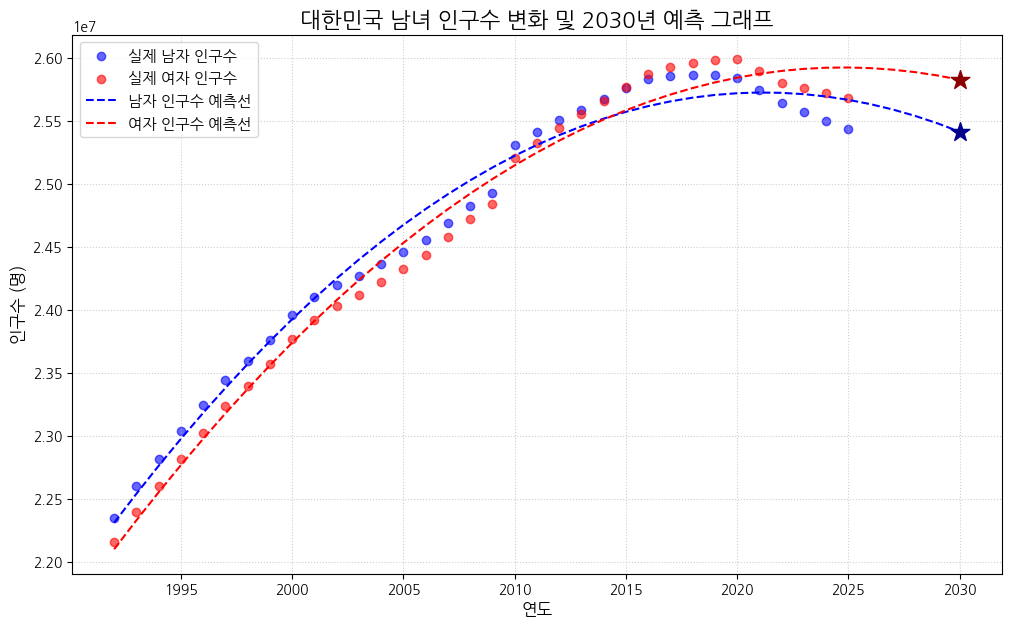

In [28]:
# 1992년부터 2030년까지의 예측선 그리기 준비
X_plot = np.arange(1992, 2031).reshape(-1, 1)
X_plot_df = pd.DataFrame(X_plot, columns=['연도'])
X_plot_poly = poly.transform(X_plot_df)

# 그래프 설정
plt.figure(figsize=(12, 7))

# 실제 데이터 점으로 찍기
plt.scatter(X, y_male, color='blue', alpha=0.6, label='실제 남자 인구수')
plt.scatter(X, y_female, color='red', alpha=0.6, label='실제 여자 인구수')

# 인공지능이 예측한 추세선 그리기
plt.plot(X_plot, model_male.predict(X_plot_poly), color='blue', linestyle='--', label='남자 인구수 예측선')
plt.plot(X_plot, model_female.predict(X_plot_poly), color='red', linestyle='--', label='여자 인구수 예측선')

plt.title('대한민국 남녀 인구수 변화 및 2030년 예측 그래프', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('인구수 (명)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 2030년 예측 지점에 강조점 표시
plt.scatter(2030, pred_male_2030, color='darkblue', marker='*', s=200, zorder=5)
plt.scatter(2030, pred_female_2030, color='darkred', marker='*', s=200, zorder=5)

plt.savefig('인구수_예측_그래프.png', dpi=300, bbox_inches='tight')
plt.show()

## 💡 결론 및 시사점 (수행평가 결과 해석)
위 데이터 분석 및 그래프 결과를 바탕으로 다음과 같은 사회적 시사점을 도출할 수 있습니다.

1. **인구 감소의 가속화**: 그래프의 추세선(점선)을 보면, 특정 시점 이후로 인구가 눈에 띄게 하락하는 곡선을 그리고 있습니다. 이는 현재 대한민국의 **저출산 문제**가 심각함을 수치로 보여줍니다.
2. **미래 사회의 변화**: 2030년에는 총인구수의 하락뿐만 아니라 생산가능인구의 급감, 노년층 부양 부담 증가 등 다양한 사회적/경제적 문제가 뒤따를 것으로 예상됩니다.
3. **대응 방안의 필요성**: 본 예측 결과는 과거의 추세를 바탕으로 한 것이지만, 이러한 비관적인 미래를 막기 위해 일가정 양립 지원, 주거 안정, 이민 정책 등 범국가적인 인구 정책 마련이 시급함을 시사합니다.